## Lec 1：Breakpoints

### LangGraph为什么需要Breakpoints
传统的 DAG（有向无环图）工作流是确定性的：输入进入，节点按拓扑序执行，结果输出。每一步都是函数调用，执行时间可预测，节点之间没有状态依赖，出错可以重新运行整个流程。这种模型在批处理、ETL、CI/CD 流水线中工作得很好。  

Agent Workflow 面临四个传统 DAG 完全没有的挑战：
- 长时间运行：一次 agent 执行可能包含数十次 LLM 调用、数百次工具调用，持续数分钟甚至数小时。你不可能让一个 HTTP 连接开着等它跑完。

- 人类参与（Human-in-the-Loop）：当 agent 准备执行"发送邮件给全部客户"或"提交 PR 到 main 分支"时，必须停下来等人类审批，时间可能是几分钟到几天。

- 工具调用风险：调用外部 API 是有副作用的。如果 agent 出错，你不能简单地"重新运行"——那会导致重复付款、重复发邮件、重复写数据库。

- LLM 的不确定性：同样的输入，每次 LLM 输出都可能不同。这意味着整个执行路径是动态的、不可预知的。

### Breakpoints 的基本概念

#### Interrupt
本质：执行暂停信号
- 在节点执行前触发
- 保存当前State
- 抛出 GraphInterrupt
- 等待外部 input

#### Checkpoint
本质：状态快照
- 每个节点后自动保存
- 包含完整State
- 包含执行元数据
- 存入Checkpointer
- 支持Time-Travel

#### Resume
本质：从快照重新执行
- 加载最新的Checkpoint
- 注入Human Input
- 从中断点重新执行
- 不重跑已完成节点

#### Checkpointer
- MemorySaver - 内存（开发用）
- SqliteSaver - 本地SQLite
- PostgresSaver - 生产PostgresSQL
- Custom Saver - Redis/MongoDB...

存储 thread_id → [ checkpoint_0, checkpoint_1, … , checkpoint_N ]  
每个 checkpoint 包含：state 完整快照 + 父节点 ID + 时间戳 + pending writes  
thread_ts 字段支持"时间旅行"回到任意历史状态

↓ 演示：interrupt / checkpoint / resume 的完整生命周期

In [3]:
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt, Command
from typing import TypedDict, Annotated
import operator

In [4]:
# 1. 定义 State 结构
class State(TypedDict):
    messages: Annotated[list, operator.add]  # reducer: 追加而非覆盖
    approved: bool

# 2. 定义节点
def draft_action(state: State):
    """第一个节点：准备一个需要审批的操作"""
    print("\n[node: draft_action] 准备执行危险操作...")
    return {"messages": ["Action: 删除所有日志文件"]}

def human_review(state: State):
    """
    第二个节点：等待人类审批
 
    interrupt() 的本质：
    - 抛出 GraphInterrupt 异常（不是错误，是信号）
    - Pregel 执行循环捕获后保存 checkpoint 并退出
    - 返回值 = 下次 resume 时传入的 Command(resume=...) 的值
    """
    print("[node: human_review] ⏸  等待人类审批...")
    decision = interrupt({
        "action": state["messages"][-1],
        "question": "确认执行此操作？(approve / reject)"
    })
    print(f"[node: human_review] 收到审批: {decision}")
    return {
        "approved": decision == "approve",
        "messages": [f"审批结果: {decision}"]
    }

def execute_action(state: State):
    """第三个节点：根据审批结果决定是否执行"""
    if state["approved"]:
        print("[node: execute_action] ✅ 已批准，正在执行...")
        return {"messages": ["操作已执行完成"]}
    else:
        print("[node: execute_action] ❌ 已拒绝，取消操作")
        return {"messages": ["操作已取消"]}

In [5]:
# 3. 构建图
builder = StateGraph(State)
builder.add_node("draft_action", draft_action)
builder.add_node("human_review", human_review)
builder.add_node("execute_action", execute_action)
 
builder.add_edge(START, "draft_action")
builder.add_edge("draft_action", "human_review")
builder.add_edge("human_review", "execute_action")
builder.add_edge("execute_action", END)
 
# Checkpointer：生产环境替换为 PostgresSaver
checkpointer = MemorySaver()
graph = builder.compile(checkpointer=checkpointer)
 
config = {"configurable": {"thread_id": "demo-thread-001"}}

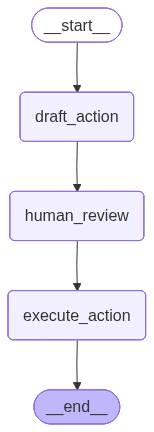

In [6]:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [7]:
# 4. 第一次执行：自动在 interrupt() 处暂停
# ============================================================
print("=" * 60)
print("▶  第一次 invoke — 执行到 interrupt 后自动暂停")
print("=" * 60)
 
result = graph.invoke(
    {"messages": [], "approved": False},
    config
)
print(f"\n返回的 __interrupt__ 信息:")
for item in result.get("__interrupt__", []):
    print(f"  value   : {item.value}")
    print(f"  id      : {item.id}")
    

▶  第一次 invoke — 执行到 interrupt 后自动暂停

[node: draft_action] 准备执行危险操作...
[node: human_review] ⏸  等待人类审批...

返回的 __interrupt__ 信息:
  value   : {'action': 'Action: 删除所有日志文件', 'question': '确认执行此操作？(approve / reject)'}
  id      : cc97b5c8da4cb3fe0356c947c74bc0cc


In [9]:
# 5. 查看 state snapshot（checkpoint）
print("\n" + "=" * 60)
print("🔍 查看当前 state snapshot（checkpoint）")
print("=" * 60)
 
snapshot = graph.get_state(config)
print(f"  next（待执行节点）: {snapshot.next}")
print(f"  values.messages  : {snapshot.values['messages']}")
print(f"  values.approved  : {snapshot.values['approved']}")
print(f"  config.thread_ts : {snapshot.config['configurable'].get('checkpoint_id', 'N/A')}")
 
# 查看所有历史 checkpoint（时间旅行）
print("\n  📜 完整 checkpoint 历史:")
for i, state in enumerate(graph.get_state_history(config)):
    print(f"    [{i}] next={state.next}, msgs={state.values['messages']}")
 
 


🔍 查看当前 state snapshot（checkpoint）
  next（待执行节点）: ('human_review',)
  values.messages  : ['Action: 删除所有日志文件']
  values.approved  : False
  config.thread_ts : 1f1599c1-71a5-6f01-8001-0b16b747bc67

  📜 完整 checkpoint 历史:
    [0] next=('human_review',), msgs=['Action: 删除所有日志文件']
    [1] next=('draft_action',), msgs=[]
    [2] next=('__start__',), msgs=[]


In [11]:
# 6. Resume：注入人类审批结果
# ============================================================
print("\n" + "=" * 60)
print("▶  第二次 invoke — Command(resume='approve') 恢复执行")
print("=" * 60)
 
result2 = graph.invoke(Command(resume="approve"), config)
print(f"\n最终 state messages: {result2['messages']}")
print(f"最终 approved      : {result2['approved']}")
 
 


▶  第二次 invoke — Command(resume='approve') 恢复执行
[node: human_review] ⏸  等待人类审批...
[node: human_review] 收到审批: approve
[node: execute_action] ✅ 已批准，正在执行...

最终 state messages: ['Action: 删除所有日志文件', '审批结果: approve', '操作已执行完成']
最终 approved      : True


In [12]:
# 7. 演示：拒绝分支
# ============================================================
print("\n" + "=" * 60)
print("▶  演示拒绝分支（新 thread）")
print("=" * 60)
 
config2 = {"configurable": {"thread_id": "demo-thread-002"}}
graph.invoke({"messages": [], "approved": False}, config2)
result3 = graph.invoke(Command(resume="reject"), config2)
print(f"拒绝后 messages: {result3['messages']}")
 


▶  演示拒绝分支（新 thread）

[node: draft_action] 准备执行危险操作...
[node: human_review] ⏸  等待人类审批...
[node: human_review] ⏸  等待人类审批...
[node: human_review] 收到审批: reject
[node: execute_action] ❌ 已拒绝，取消操作
拒绝后 messages: ['Action: 删除所有日志文件', '审批结果: reject', '操作已取消']


In [14]:
# 8. 演示 interrupt_before（另一种 Breakpoint 模式）

print("\n" + "=" * 60)
print("▶  interrupt_before 模式（编译时声明断点）")
print("=" * 60)
 
# 重新编译，在 execute_action 之前强制暂停
graph_with_breakpoint = builder.compile(
    checkpointer=checkpointer,
    interrupt_before=["execute_action"]   # 声明式断点
)
 
config3 = {"configurable": {"thread_id": "demo-thread-003"}}
r = graph_with_breakpoint.invoke({"messages": [], "approved": True}, config3)
snap3 = graph_with_breakpoint.get_state(config3)
print(f"  暂停位置: {snap3.next}")
 
# 直接 resume（不修改 state）
r_final = graph_with_breakpoint.invoke(None, config3)
print(f"  最终 messages: {r_final['messages']}")
 
print("\n Demo Done")


▶  interrupt_before 模式（编译时声明断点）

[node: draft_action] 准备执行危险操作...
[node: human_review] ⏸  等待人类审批...
  暂停位置: ('human_review',)
[node: human_review] ⏸  等待人类审批...
  最终 messages: ['Action: 删除所有日志文件', 'Action: 删除所有日志文件']

 Demo Done
